# Latent Space Exploration

Follow-up exercise

1. **Interpolate** between two real digits in latent space (and compare to pixel-space averaging).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
print(f"Device: {device}")

Device: cuda


## Latent Interpolation

Given two real digits $x_a, x_b$, encode them to $\mu_a, \mu_b$, walk along the line between them in latent space, and decode every step. A well-trained VAE produces a smooth morph through plausible digits

In [2]:
class VAE(nn.Module): # same model as in 02_VAE_2D
    def __init__(self, x_dim=784, h_dim1=512, h_dim2=256, z_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(x_dim, h_dim1)
        self.fc2 = nn.Linear(h_dim1, h_dim2)
        self.fc31 = nn.Linear(h_dim2, z_dim)
        self.fc32 = nn.Linear(h_dim2, z_dim)
        self.fc4 = nn.Linear(z_dim, h_dim2)
        self.fc5 = nn.Linear(h_dim2, h_dim1)
        self.fc6 = nn.Linear(h_dim1, x_dim)

    def encoder(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.fc31(h), self.fc32(h)

    def decoder(self, z):
        h = F.relu(self.fc4(z))
        h = F.relu(self.fc5(h))
        return torch.sigmoid(self.fc6(h))

vae = VAE().to(device)
vae.load_state_dict(torch.load("fc_vae_2d.pth", map_location=device))
vae.eval()
print("Loaded fc_vae_2d.pth")

Loaded fc_vae_2d.pth


In [3]:
test_ds = datasets.MNIST(root="./data/", train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
print(f"Test set: {len(test_ds)} images")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:01<00:00, 9.87MB/s]


Test set: 10000 images


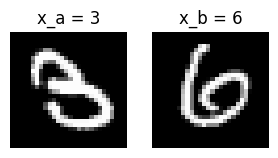

In [4]:
def first_of_class(ds, cls, skip=0):
    seen = 0
    for img, lbl in ds:
        if lbl == cls:
            if seen == skip:
                return img
            seen += 1

CLASS_A, CLASS_B = 3, 6     # try (4, 9), (1, 7), (0, 6) ...
img_a = first_of_class(test_ds, CLASS_A).to(device)
img_b = first_of_class(test_ds, CLASS_B).to(device)

fig, ax = plt.subplots(1, 2, figsize=(3, 1.6))
ax[0].imshow(img_a.cpu().squeeze(), cmap="gray"); ax[0].set_title(f"x_a = {CLASS_A}"); ax[0].axis("off")
ax[1].imshow(img_b.cpu().squeeze(), cmap="gray"); ax[1].set_title(f"x_b = {CLASS_B}"); ax[1].axis("off")
plt.tight_layout(); plt.show()

  mu_a = (-0.998, +1.740)  (digit 3)
  mu_b = (+0.094, +1.005)  (digit 6)

  step      t        z1        z2
  ----  -----  --------  --------
     0   0.00    -0.998    +1.740
     1   0.05    -0.941    +1.701
     2   0.11    -0.883    +1.663
     3   0.16    -0.826    +1.624
     4   0.21    -0.769    +1.585
     5   0.26    -0.711    +1.547
     6   0.32    -0.654    +1.508
     7   0.37    -0.596    +1.469
     8   0.42    -0.539    +1.431
     9   0.47    -0.481    +1.392
    10   0.53    -0.424    +1.353
    11   0.58    -0.366    +1.315
    12   0.63    -0.309    +1.276
    13   0.68    -0.251    +1.237
    14   0.74    -0.194    +1.198
    15   0.79    -0.136    +1.160
    16   0.84    -0.079    +1.121
    17   0.89    -0.021    +1.082
    18   0.95    +0.036    +1.044
    19   1.00    +0.094    +1.005


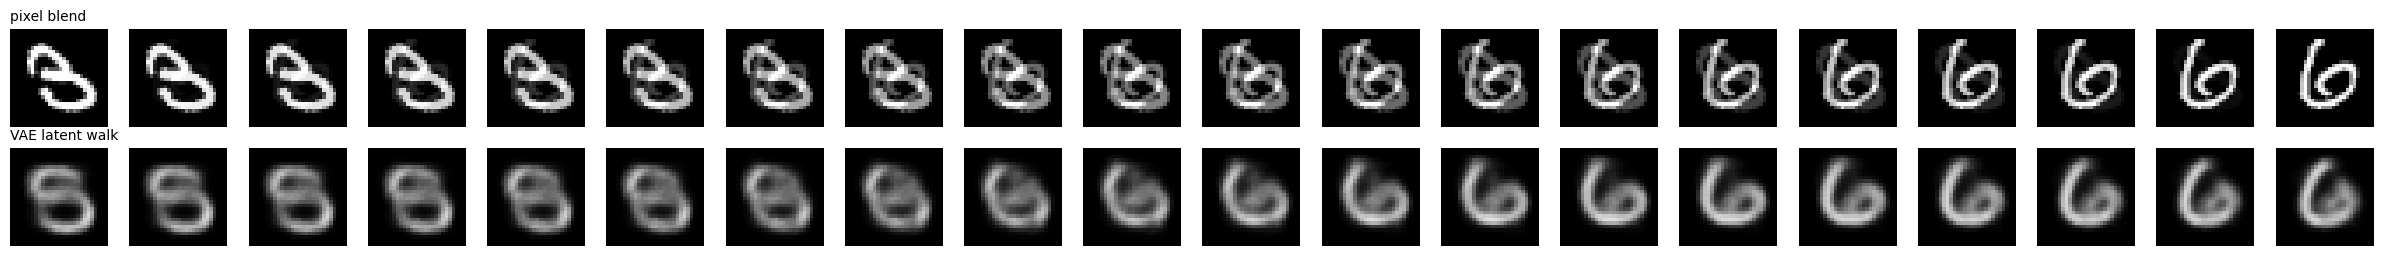

In [5]:
N_STEPS = 20

with torch.no_grad():
    mu_a, _ = vae.encoder(img_a.view(1, -1))
    mu_b, _ = vae.encoder(img_b.view(1, -1))

ts = torch.linspace(0, 1, N_STEPS, device=device).unsqueeze(1)
z_path = (1 - ts) * mu_a + ts * mu_b                 # latent-space line
with torch.no_grad():
    decoded = vae.decoder(z_path).view(-1, 28, 28).cpu()

# Pixel-space linear blend, for comparison
pixel_blend = ((1 - ts.view(-1, 1, 1)).cpu() * img_a.view(1, 28, 28).cpu()
               +  ts.view(-1, 1, 1).cpu()      * img_b.view(1, 28, 28).cpu())

# Print the actual 2-D latent coordinate at each step
print(f"  mu_a = ({mu_a[0,0].item():+.3f}, {mu_a[0,1].item():+.3f})  (digit {CLASS_A})")
print(f"  mu_b = ({mu_b[0,0].item():+.3f}, {mu_b[0,1].item():+.3f})  (digit {CLASS_B})")
print()
print(f"  {'step':>4s}  {'t':>5s}  {'z1':>8s}  {'z2':>8s}")
print(f"  {'-'*4}  {'-'*5}  {'-'*8}  {'-'*8}")
zp = z_path.cpu()
for j in range(N_STEPS):
    print(f"  {j:>4d}  {ts[j,0].item():>5.2f}  {zp[j,0].item():>+8.3f}  {zp[j,1].item():>+8.3f}")

fig, axes = plt.subplots(2, N_STEPS, figsize=(1.2 * N_STEPS, 2.6))
for j in range(N_STEPS):
    axes[0, j].imshow(pixel_blend[j], cmap="gray", vmin=0, vmax=1); axes[0, j].axis("off")
    axes[1, j].imshow(decoded[j],     cmap="gray", vmin=0, vmax=1); axes[1, j].axis("off")
axes[0, 0].set_title("pixel blend", loc="left", fontsize=10)
axes[1, 0].set_title("VAE latent walk", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

^ the transition from 3 to 6 should be smooth (every picture a reasonable output/number; second row)

we are not really staring with 3 but we at least arrive at 6

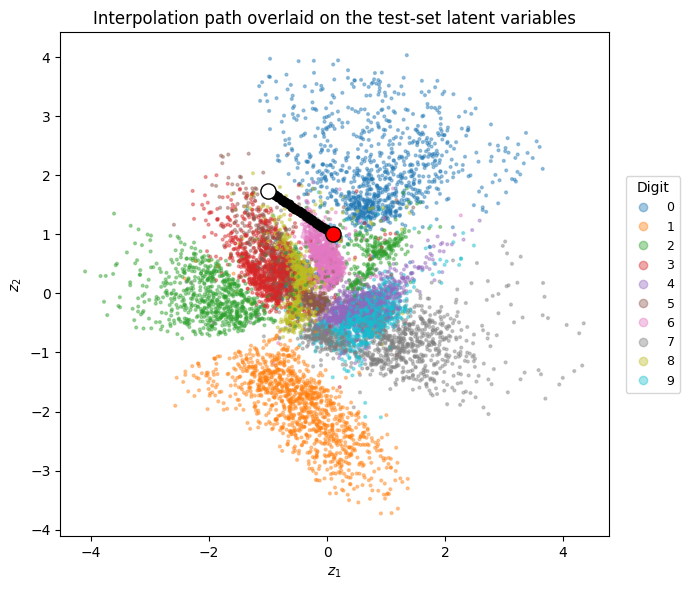

In [6]:
# Show the interpolation path on the latent scatter
all_mu, all_lbl = [], []
with torch.no_grad():
    for x, y in test_loader:
        mu, _ = vae.encoder(x.to(device).view(-1, 784))
        all_mu.append(mu.cpu()); all_lbl.append(y)
all_mu = torch.cat(all_mu).numpy()
all_lbl = torch.cat(all_lbl).numpy()

z_np = z_path.cpu().numpy()
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(all_mu[:, 0], all_mu[:, 1], c=all_lbl, cmap="tab10", s=4, alpha=0.4)
ax.plot(z_np[:, 0], z_np[:, 1], "k--", lw=1.5)
ax.scatter(z_np[:, 0], z_np[:, 1], c="black", s=40, zorder=3)
ax.scatter([z_np[0, 0]], [z_np[0, 1]], c="white", edgecolors="black", s=120, zorder=4, label=f"x_a ({CLASS_A})")
ax.scatter([z_np[-1, 0]], [z_np[-1, 1]], c="red", edgecolors="black", s=120, zorder=4, label=f"x_b ({CLASS_B})")
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("Interpolation path overlaid on the test-set latent variables")
ax.legend(*sc.legend_elements(), title="Digit", loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.tight_layout(); plt.show()